# 1. Loading the Cleaned Train Dataset

In [52]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Load cleaned dataset
df_train = pd.read_csv("data\data_clean.csv")
df_test = pd.read_csv("data\\test_clean.csv")
df_train.head()


<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\d'
C:\Users\abina\AppData\Local\Temp\ipykernel_26344\238400901.py:8: SyntaxWarning: invalid escape sequence '\d'
  df_train = pd.read_csv("data\data_clean.csv")


,customer_id,age,gender,country,tenure_months,monthly_spend,num_transactions,last_login_days,support_tickets,payment_method,is_active,total_spend,avg_transaction_value,target_churn,target_revenue,target_fraud,suspicion_score
0,1502,59,Male,Germany,2,185.360890,52,18,5,PayPal,0,370.721781,6.994751,1,382.034265,0,0.0
1,2587,25,Female,US,54,108.879222,35,17,7,Card,1,5879.477977,163.318833,0,217.996705,1,0.0
2,2654,38,Female,Germany,48,221.927474,5,2,5,PayPal,1,10652.518741,1775.419790,0,208.955628,0,0.0
3,1056,48,Male,US,26,275.346433,14,26,5,Card,1,7159.007247,477.267150,0,248.913546,0,0.0
4,706,53,Male,UK,15,444.016783,95,20,0,Card,1,6660.251746,69.377622,0,768.714022,0,0.3


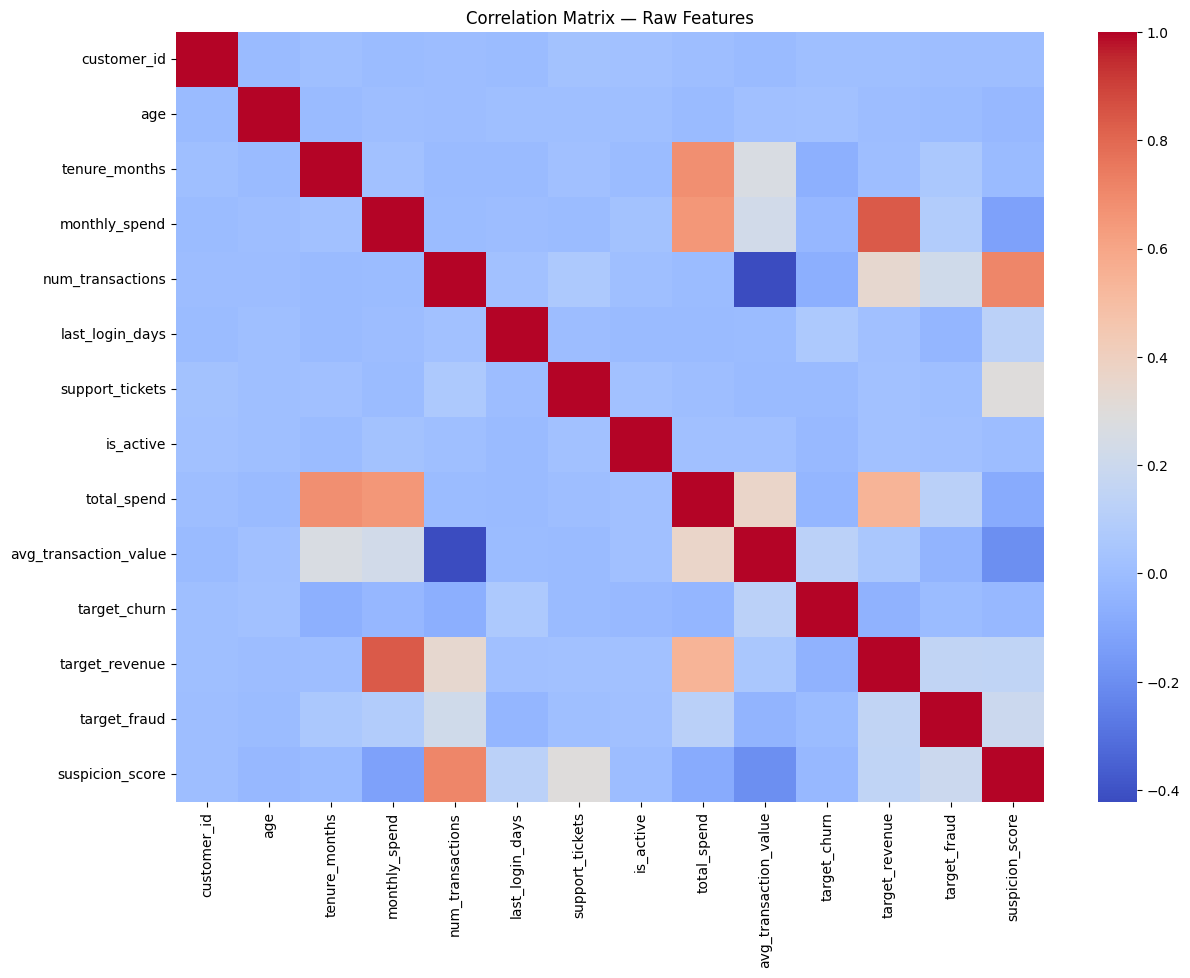

In [53]:
#Raw Correlation Matrix (Before Engineering)

df_train_raw = df_train.copy()

plt.figure(figsize=(14,10))
sns.heatmap(df_train_raw.select_dtypes(include=np.number).corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Matrix — Raw Features")
plt.show()



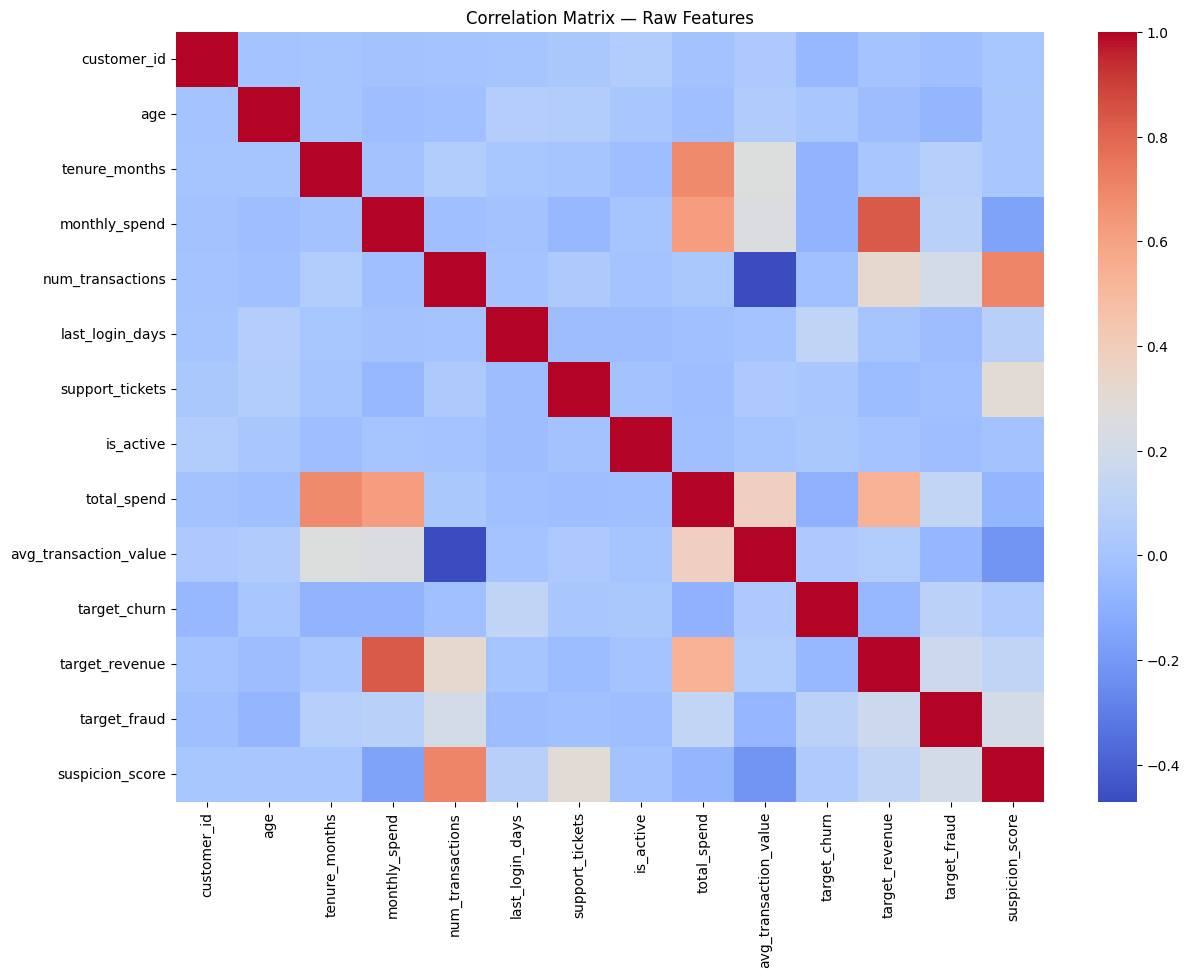

In [54]:
df_test_raw = df_test.copy()

plt.figure(figsize=(14,10))
sns.heatmap(df_test_raw.select_dtypes(include=np.number).corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Matrix — Raw Features")
plt.show()

## 1.2. Core Behavioural Features (Transaction Intensity)

In [55]:
cols_to_drop = [
    'customer_id',             # identifier
    'avg_transaction_value',   # weak signal
    'gender',                  # replaced by gender_binary
    'country',                 # encoded
    'payment_method',          # encoded
    'target_churn',            # target variable
    'target_revenue',          # target variable
    'total_spend',
    'num_transactions'
]

In [56]:
def featuring(df):
        # =====================================================
    # 1. CORE BEHAVIOR FEATURES (STRONG SIGNAL ONLY)
    # =====================================================

    df['txn_per_day'] = df['num_transactions'] / (df['last_login_days'] + 1)

    df['spend_per_txn'] = df['total_spend'] / (df['num_transactions'] + 1)

    df['spend_per_day'] = df['total_spend'] / (df['last_login_days'] + 1)

    df['support_intensity'] = np.log1p(df['support_tickets'])

    # =====================================================
    # 2. LOG STABILITY FEATURES
    # =====================================================

    df['log_spend'] = np.log1p(df['total_spend'])
    df['log_txn'] = np.log1p(df['num_transactions'])

    # =====================================================
    # 3. HIGH-IMPACT CONTRAST FEATURES (VERY IMPORTANT FOR PR-AUC)
    # =====================================================

    df['high_spender_flag'] = (df['total_spend'] > df['total_spend'].quantile(0.8)).astype(int)

    df['inactive_high_spender'] = (
        (df['total_spend'] > df['total_spend'].median()) &
        (df['last_login_days'] > df['last_login_days'].median())
    ).astype(int)

    df['support_per_txn'] = df['support_tickets'] / (df['num_transactions'] + 1)

    df['txn_spend_ratio'] = df['num_transactions'] / (df['total_spend'] + 1)

    # =====================================================
    # 4. MINIMAL INTERACTIONS (KEEP ONLY STRONG ONES)
    # =====================================================

    df['activity_score'] = df['log_spend'] * df['log_txn']

    df['risk_score'] = df['support_intensity'] * df['txn_per_day']

    # =====================================================
    # 5. GROUP DEVIATION FEATURES (STABLE VERSION)
    # =====================================================

    country_mean_spend = df.groupby('country')['monthly_spend'].transform('mean')
    country_std_spend = df.groupby('country')['monthly_spend'].transform('std')

    df['spend_country_z'] = (df['monthly_spend'] - country_mean_spend) / (country_std_spend + 1e-6)

    country_mean_txn = df.groupby('country')['num_transactions'].transform('mean')
    country_std_txn = df.groupby('country')['num_transactions'].transform('std')

    df['txn_country_z'] = (df['num_transactions'] - country_mean_txn) / (country_std_txn + 1e-6)

    # =====================================================
    # 6. SAFE ENCODING (LEAKAGE-FREE FREQUENCY ENCODING)
    # =====================================================

    df['gender_binary'] = df['gender'].map({'Male': 1, 'Female': 0})

    country_freq = df['country'].value_counts(normalize=True)
    df['country_freq'] = df['country'].map(country_freq)

    pm_freq = df['payment_method'].value_counts(normalize=True)
    df['pm_freq'] = df['payment_method'].map(pm_freq)


    df = df.drop(columns=cols_to_drop)

    return df

In [57]:
df_train = featuring(df_train)
df_test = featuring(df_test)


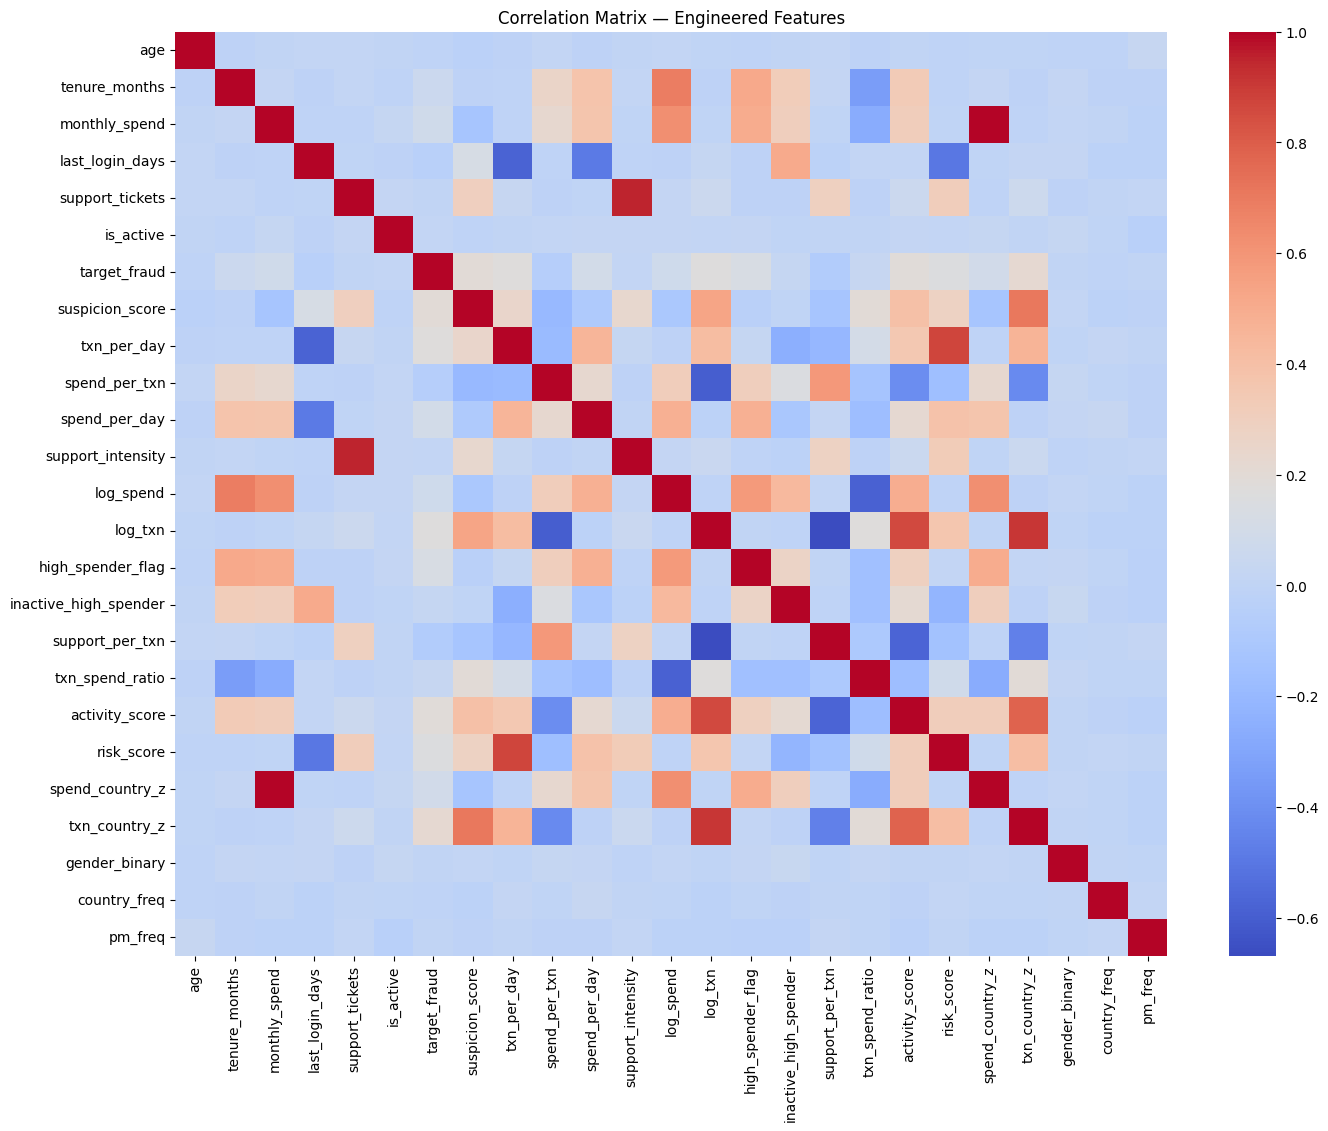

In [58]:
# Engineered Feature Correlation Matrix

plt.figure(figsize=(16,12))
sns.heatmap(df_train.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Matrix — Engineered Features")
plt.show()


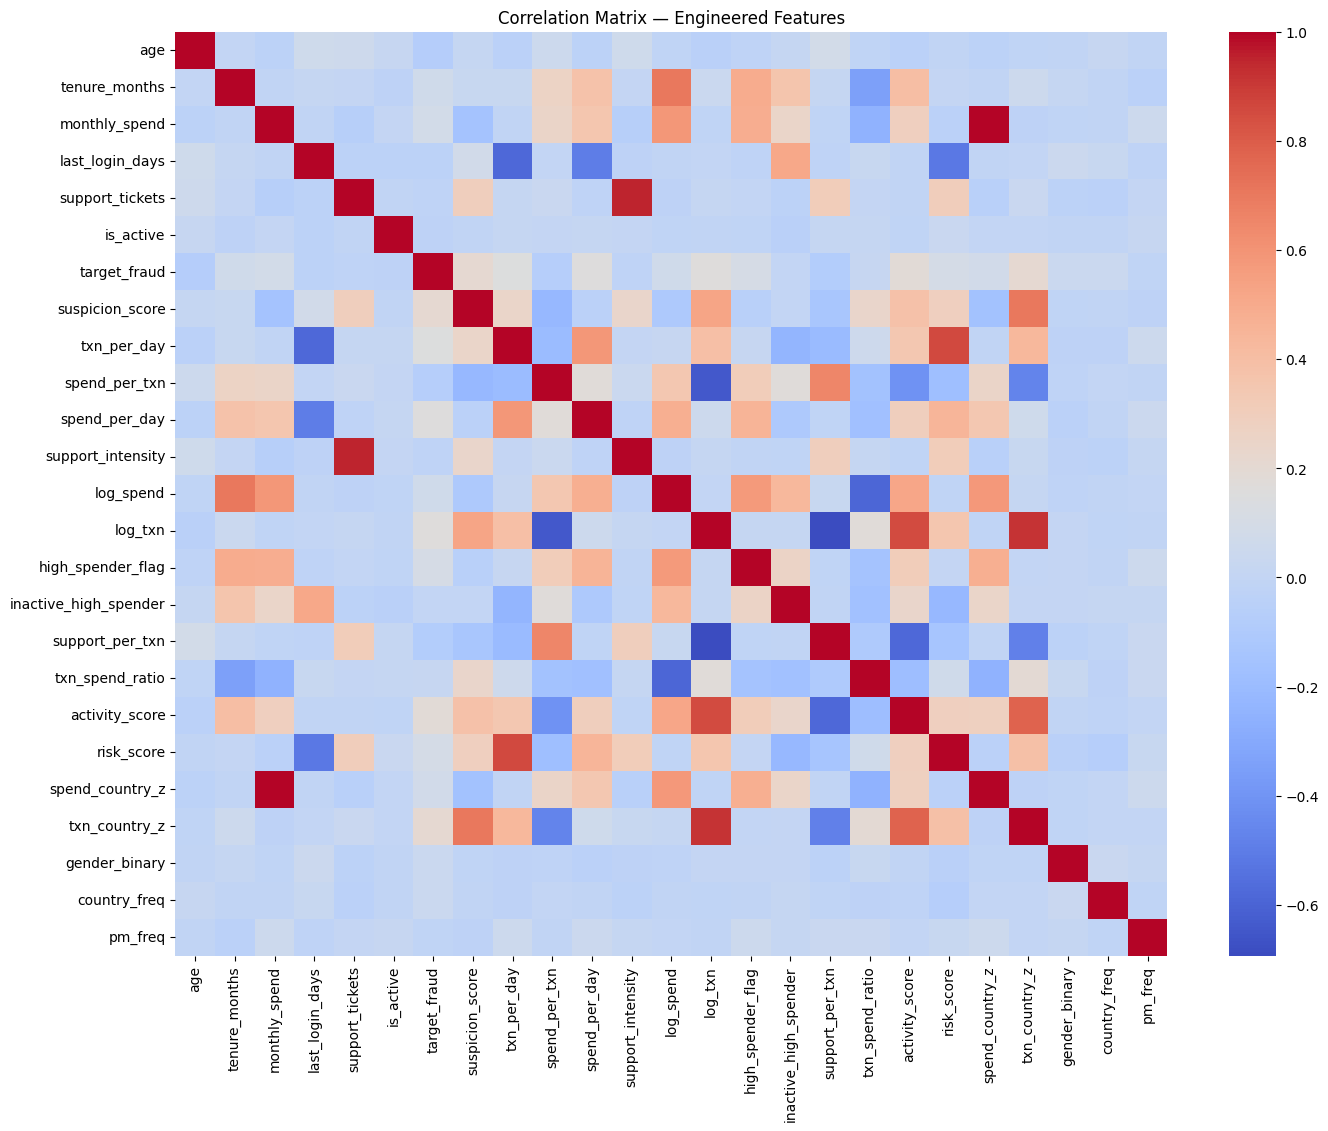

In [59]:
plt.figure(figsize=(16,12))
sns.heatmap(df_test.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Matrix — Engineered Features")
plt.show()


In [60]:
# Feature vs Target Correlation Ranking

df_train.corr()['target_fraud'].sort_values(ascending=False)


target_fraud             1.000000
txn_country_z            0.218482
suspicion_score          0.196691
activity_score           0.190214
txn_per_day              0.178526
log_txn                  0.168582
risk_score               0.153263
high_spender_flag        0.132314
spend_per_day            0.100411
spend_country_z          0.088087
monthly_spend            0.086591
log_spend                0.077953
tenure_months            0.057183
txn_spend_ratio          0.028877
inactive_high_spender    0.023219
support_intensity        0.012934
is_active                0.011406
support_tickets          0.009230
gender_binary            0.007658
pm_freq                  0.003104
country_freq            -0.005064
age                     -0.007900
last_login_days         -0.038192
spend_per_txn           -0.049767
support_per_txn         -0.070788
Name: target_fraud, dtype: float64

In [61]:

df_test.corr()['target_fraud'].sort_values(ascending=False)

target_fraud             1.000000
txn_country_z            0.209447
suspicion_score          0.208929
activity_score           0.184869
log_txn                  0.163040
spend_per_day            0.158538
txn_per_day              0.147282
high_spender_flag        0.102978
risk_score               0.099355
monthly_spend            0.081256
spend_country_z          0.080412
tenure_months            0.071465
log_spend                0.069942
gender_binary            0.035611
country_freq             0.034727
txn_spend_ratio          0.017148
inactive_high_spender   -0.003076
pm_freq                 -0.013350
support_tickets         -0.020138
support_intensity       -0.021435
is_active               -0.028642
last_login_days         -0.034330
spend_per_txn           -0.065739
age                     -0.074230
support_per_txn         -0.079192
Name: target_fraud, dtype: float64

In [62]:
feature_cols = df_train.columns
feature_cols
feature_cols = np.delete(feature_cols, np.where(feature_cols == 'target_fraud'))

In [63]:
scaler = StandardScaler()

train_scaled = scaler.fit_transform(df_train[feature_cols])

test_scaled = scaler.transform(df_test[feature_cols])



## 2.7. Save Scaleed Test Engineering Dataset

In [64]:
train_scaled = pd.DataFrame(train_scaled, columns=feature_cols )
train_scaled['target_fraud'] = df_train['target_fraud']
train_scaled.to_csv("feature_engineering_datasets/train_scaled.csv", index=False)

In [65]:
test_scaled = pd.DataFrame(test_scaled, columns=feature_cols)
test_scaled['target_fraud'] = df_test['target_fraud']
test_scaled.to_csv("feature_engineering_datasets/test_scaled.csv", index=False)

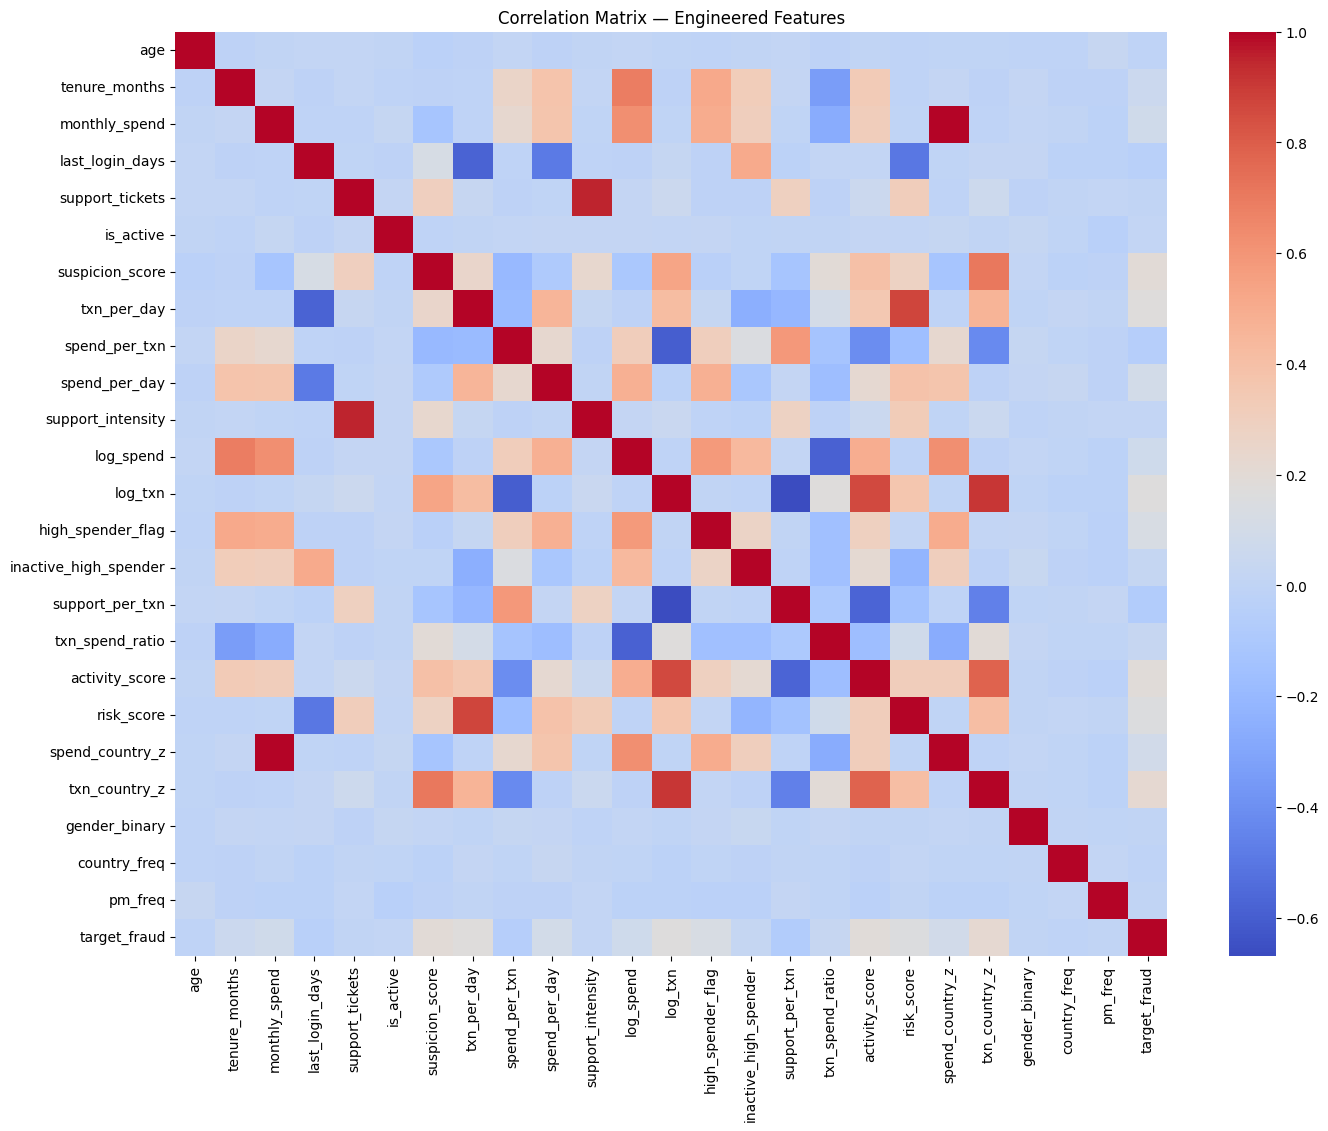

In [66]:
plt.figure(figsize=(16,12))
sns.heatmap(train_scaled.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Matrix — Engineered Features")
plt.show()


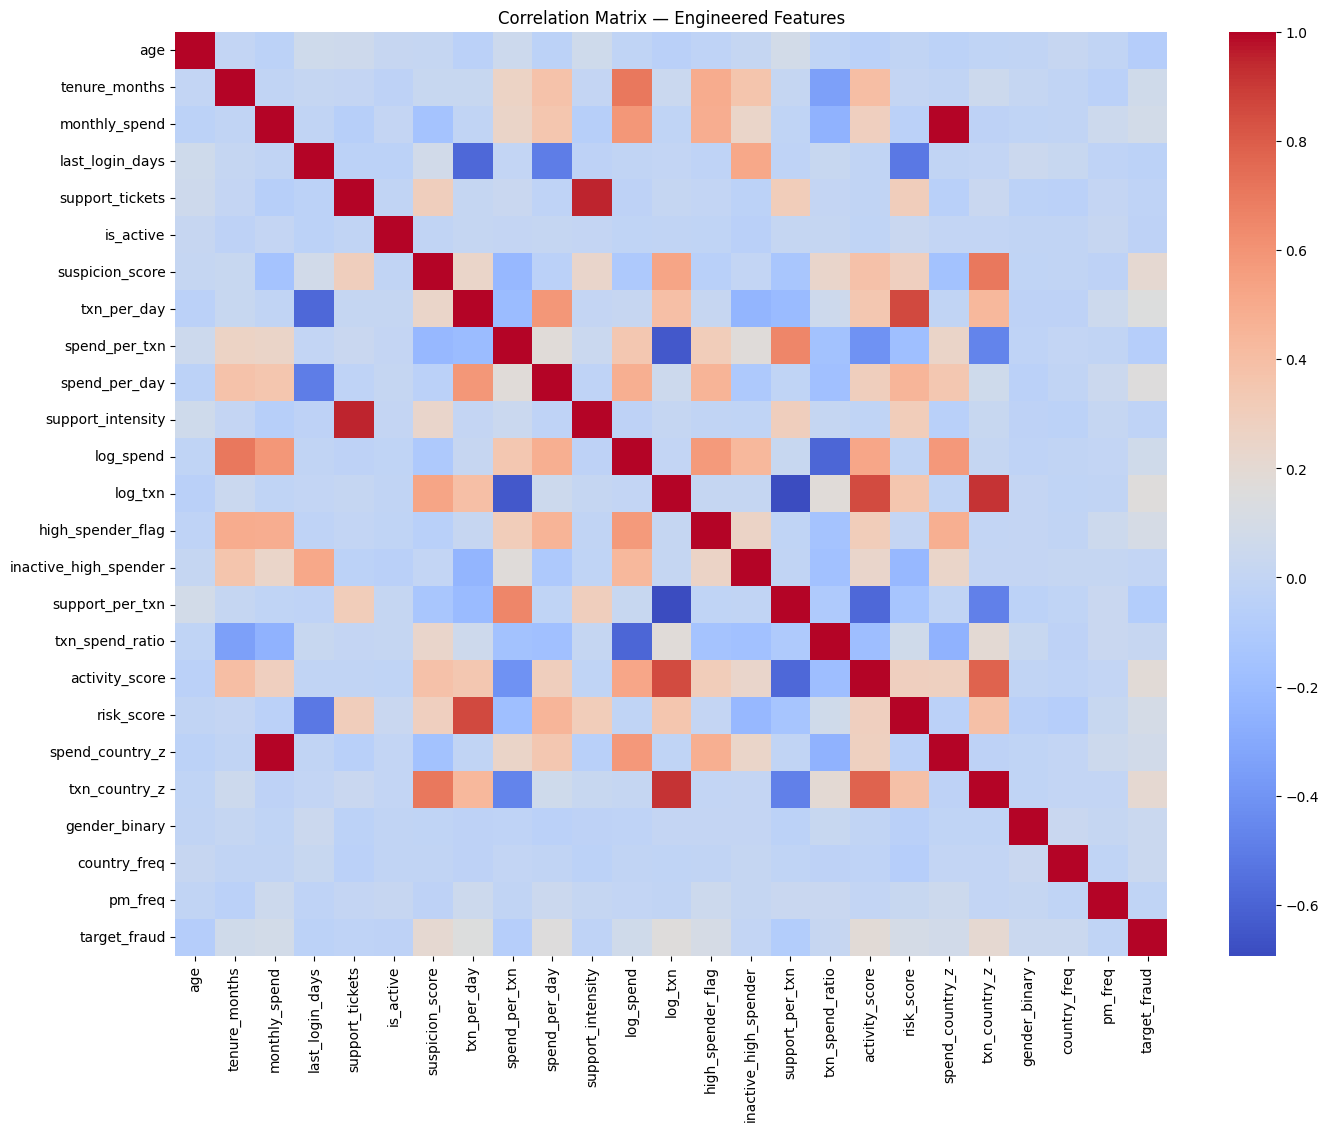

In [67]:
plt.figure(figsize=(16,12))
sns.heatmap(test_scaled.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Matrix — Engineered Features")
plt.show()

## 3.8. Save the scaler and PCA objects (critical for deployment)

In [68]:
import joblib
joblib.dump(scaler, "models/scaler.pkl")


['models/scaler.pkl']